Dataset Preview:
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p      

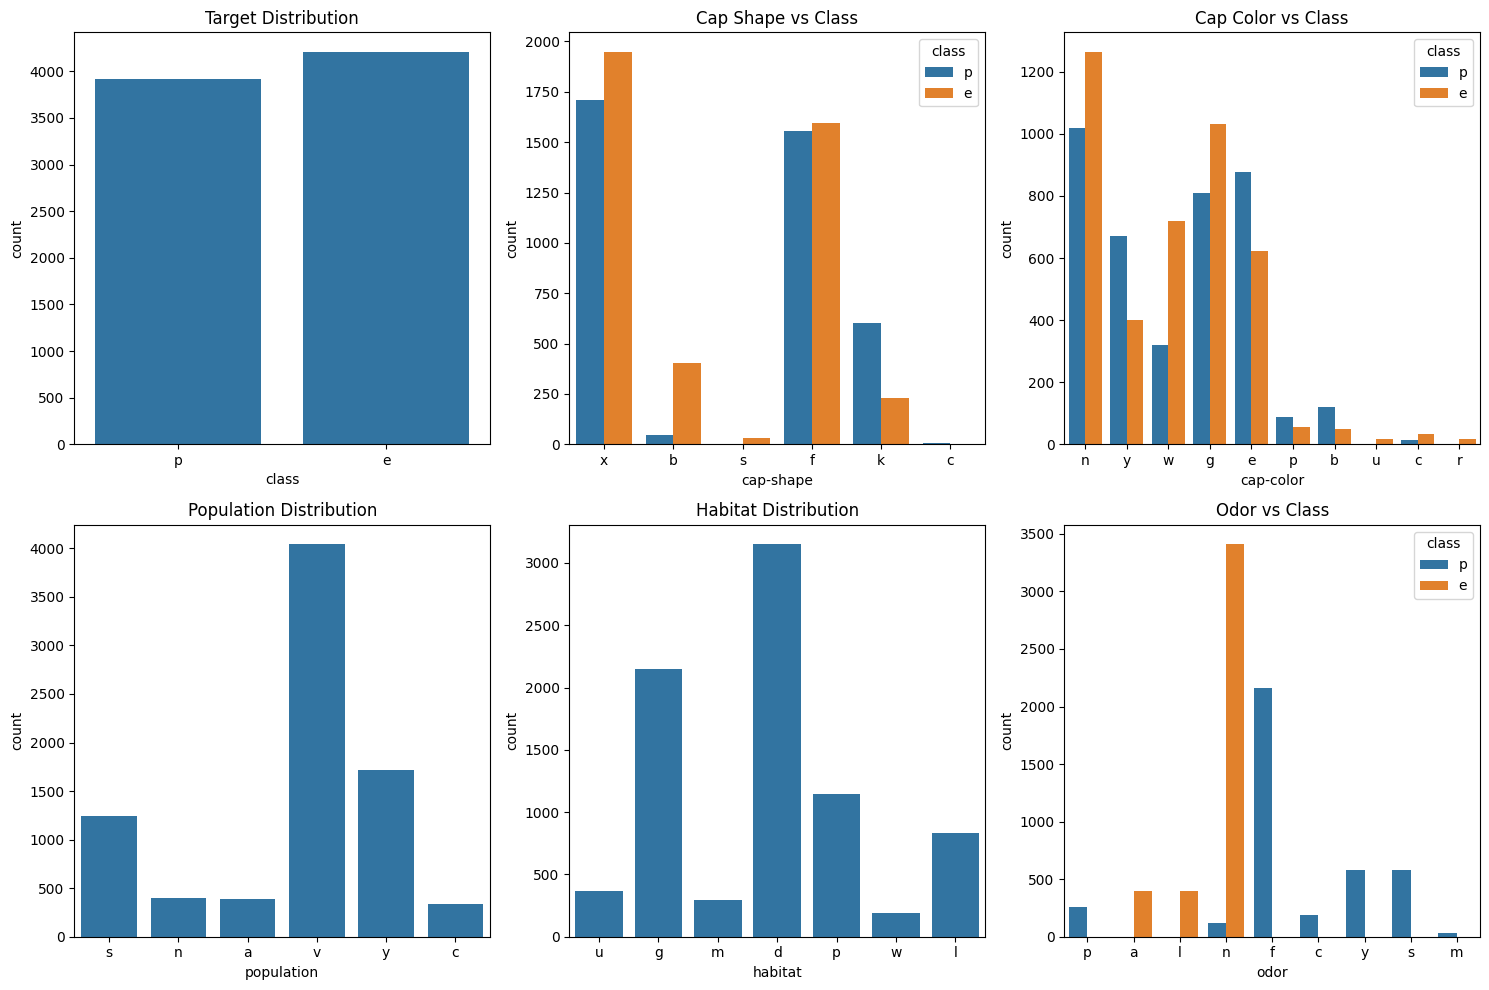

KMeans Accuracy: 0.7090


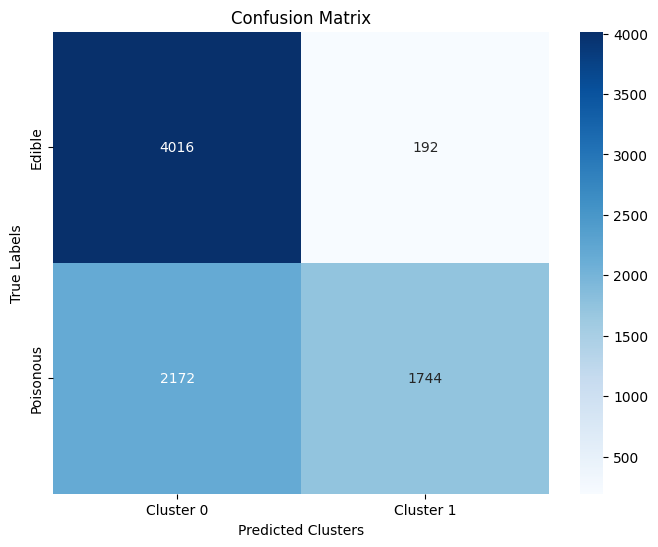


Classification Report:
              precision    recall  f1-score   support

      Edible       0.65      0.95      0.77      4208
   Poisonous       0.90      0.45      0.60      3916

    accuracy                           0.71      8124
   macro avg       0.77      0.70      0.68      8124
weighted avg       0.77      0.71      0.69      8124



In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import confusion_matrix, classification_report

# Step 1: Load the dataset
mushroom_data = pd.read_csv("/content/mushrooms.csv")
# Display first few rows
print("Dataset Preview:")
print(mushroom_data.head())

# Step 2: Check for missing values
print("\nMissing Values in Each Column:")
print(mushroom_data.isnull().sum())

print(f"Dataset shape: {mushroom_data.shape}")
print(f"Target distribution:\n{mushroom_data['class'].value_counts()}")

plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
sns.countplot(data=mushroom_data, x='class')
plt.title('Target Distribution')
plt.subplot(2, 3, 2)
sns.countplot(data=mushroom_data, x='cap-shape', hue='class')
plt.title('Cap Shape vs Class')
plt.subplot(2, 3, 3)
sns.countplot(data=mushroom_data, x='cap-color', hue='class')
plt.title('Cap Color vs Class')


plt.subplot(2, 3, 4)

sns.countplot(data=mushroom_data, x='population')

plt.title('Population Distribution')
plt.subplot(2, 3, 5)

sns.countplot(data=mushroom_data, x='habitat')

plt.title('Habitat Distribution')
plt.subplot(2, 3, 6)

sns.countplot(data=mushroom_data, x='odor', hue='class')

plt.title('Odor vs Class')

plt.tight_layout()
plt.show()

#  Handle missing values
mushroom_df = mushroom_data.dropna()
# Separate features and target
mushroom_features = mushroom_df.drop('class', axis=1)
mushroom_labels = mushroom_df['class']
# Encode categorical features
encoder = OrdinalEncoder()
mushroom_prepared = encoder.fit_transform(mushroom_features)
mushroom_prep_df = pd.DataFrame(mushroom_prepared,
columns=mushroom_features.columns)

# Create and fit KMeans model
k_clust = KMeans(n_clusters=2, random_state=42)

k_clust.fit(mushroom_prep_df)

# Get results
k_labels = k_clust.labels_


 # Map true labels to numerical values
map_dict = {'e': 0, 'p': 1}
true_labels = mushroom_labels.map(map_dict)
from sklearn.metrics import accuracy_score
# Calculate accuracy
accuracy = accuracy_score(true_labels, k_labels)
print(f"KMeans Accuracy: {accuracy:.4f}")

plt.figure(figsize=(8, 6))

cm = confusion_matrix(true_labels, k_labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cluster 0', 'Cluster 1'], yticklabels=['Edible', 'Poisonous'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted Clusters')
plt.ylabel('True Labels')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(true_labels, k_labels, target_names=['Edible', 'Poisonous']))


Dataset Preview:
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p      

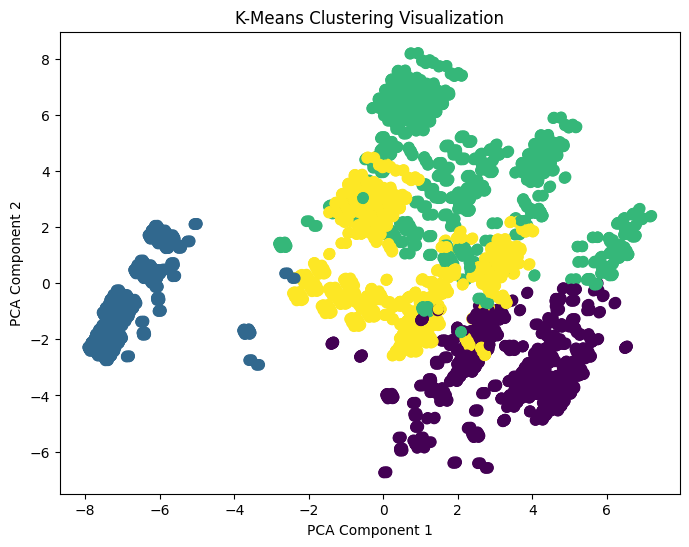

In [ ]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset
data = pd.read_csv("mushrooms.csv")

# Display first few rows
print("Dataset Preview:")
print(data.head())

# Step 2: Check for missing values
print("\nMissing Values in Each Column:")
print(data.isnull().sum())

# Step 3: Encode categorical features (if any)
label_encoders = {}
for column in data.columns:
     if data[column].dtype == 'object':
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le

# Step 4: Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(data)

# Step 5: Display cluster centers and counts
print("\nCluster Centers:\n", kmeans.cluster_centers_)
print("\nCluster Counts:\n", data['Cluster'].value_counts())


# Step 6: Visualize clusters using PCA (2D)
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(data.drop('Cluster', axis=1))
plt.figure(figsize=(8,6))
plt.scatter(reduced_data[:,0], reduced_data[:,1], c=data['Cluster'], cmap='viridis', s=50)
plt.title('K-Means Clustering Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()






Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


KMeans (raw) inertia: 44448.45544793369
Silhouette score (raw features): 0.553931997444648


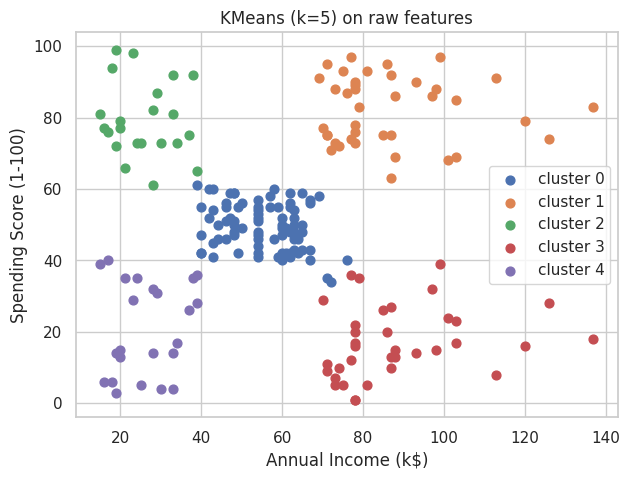

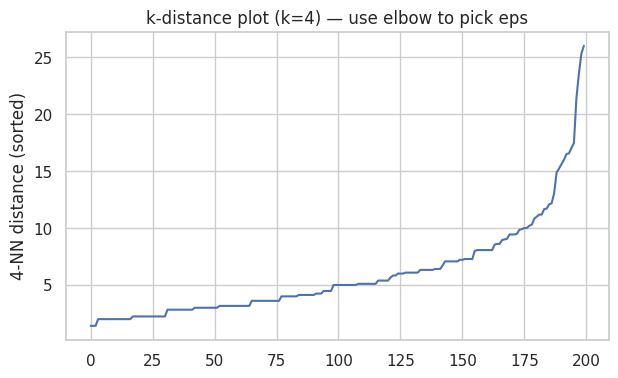

DBSCAN unique labels (raw): [-1  0  1  2]


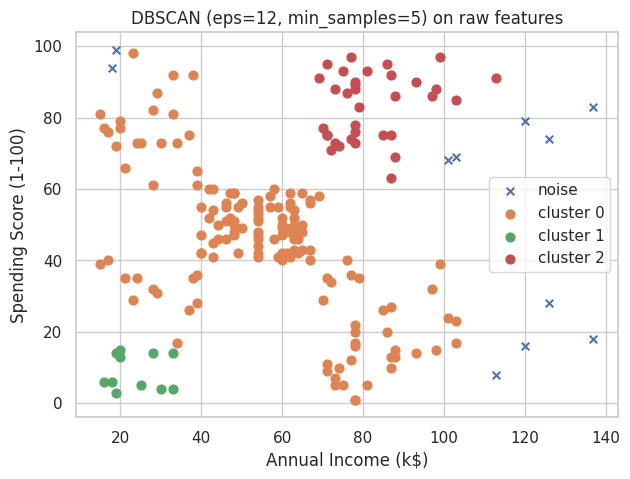

KMeans (scaled) inertia (on scaled data): 65.56840815571681
Silhouette score (scaled features): 0.5546571631111091


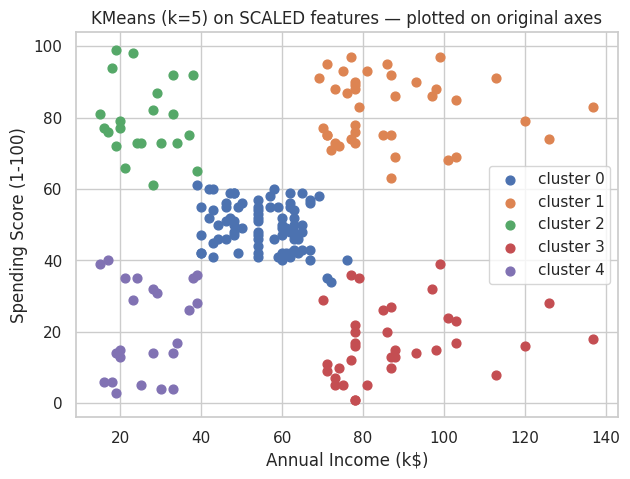

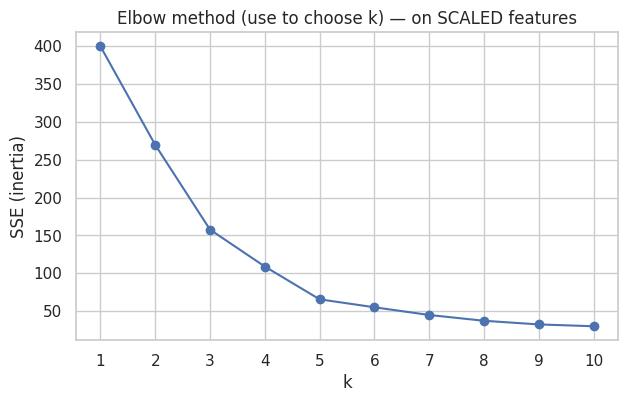

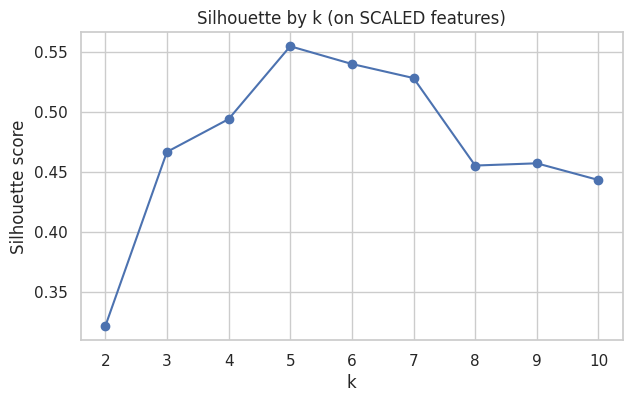

Silhouette (k=5) on 2 features (scaled): 0.5547
Silhouette (k=5) on 3 features (scaled, includes LuckyNumber): 0.3396
Number of samples with different cluster labels when adding LuckyNumber: 156 / 200


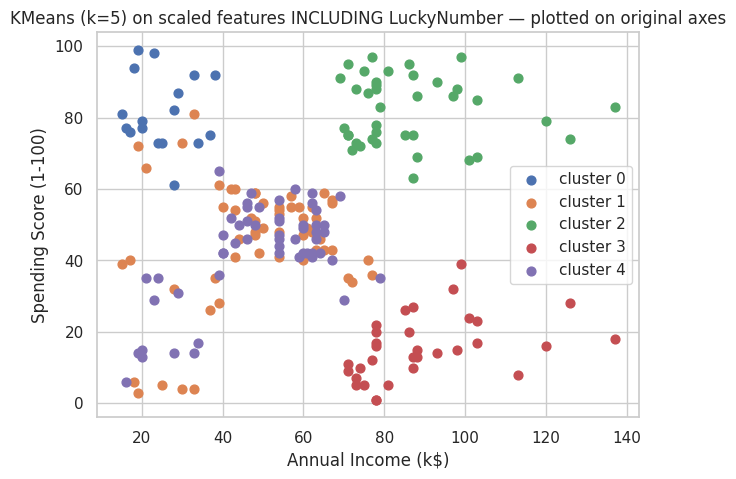

,CustomerID,Annual Income (k$),Spending Score (1-100),LuckyNumber,cluster_k_2features,cluster_k_with_lucky
0,1,15,39,9,4,1
1,2,15,81,78,2,0
2,3,16,6,66,4,4
3,4,16,77,44,2,0
4,5,17,40,43,4,1


In [ ]:
# Requirements:
# pip install pandas numpy matplotlib scikit-learn seaborn
# Put 'Mall_Customers.csv' in the working directory. Typical column names used below:
# 'CustomerID','Gender','Age','Annual Income (k$)','Spending Score (1-100)'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

sns.set(style="whitegrid")

# 1) Load dataset and display head
df = pd.read_csv("Mall_Customers.csv")
print("Dataset shape:", df.shape)
display(df.head())

# We'll cluster using these two features:
X_raw = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# helper plot function
def plot_clusters(X, labels, title, ax=None):
    if ax is None:
        plt.figure(figsize=(7,5))
    else:
        plt.sca(ax)
    unique_labels = np.unique(labels)
    for lab in unique_labels:
        mask = labels == lab
        if lab == -1:
            # noise for DBSCAN
            plt.scatter(X[mask,0], X[mask,1], s=30, marker='x', label='noise')
        else:
            plt.scatter(X[mask,0], X[mask,1], s=40, label=f'cluster {lab}')
    plt.xlabel('Annual Income (k$)')
    plt.ylabel('Spending Score (1-100)')
    plt.title(title)
    plt.legend()
    if ax is None:
        plt.show()

# 2) K-Means on raw features (no scaling)
k = 5  # common starting choice for this dataset
kmeans_raw = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_k_raw = kmeans_raw.fit_predict(X_raw)

print("KMeans (raw) inertia:", kmeans_raw.inertia_)
try:
    sil_raw = silhouette_score(X_raw, labels_k_raw)
    print("Silhouette score (raw features):", sil_raw)
except Exception as e:
    print("Silhouette score not computable:", e)

plot_clusters(X_raw, labels_k_raw, f'KMeans (k={k}) on raw features')

# 3) DBSCAN on raw features
# Use k-distance plot to choose eps:
neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(X_raw)
distances, indices = nbrs.kneighbors(X_raw)
dist_k = np.sort(distances[:, -1])
plt.figure(figsize=(7,4))
plt.plot(dist_k)
plt.ylabel('4-NN distance (sorted)')
plt.title('k-distance plot (k=4) — use elbow to pick eps')
plt.show()

# Based on the above visual, set eps. Typical choices for this dataset might be ~10-15,
# but it depends on the scale of your data. We'll pick eps=12 and min_samples=5 as an example.
dbscan = DBSCAN(eps=12, min_samples=5)
labels_db = dbscan.fit_predict(X_raw)
print("DBSCAN unique labels (raw):", np.unique(labels_db))
plot_clusters(X_raw, labels_db, 'DBSCAN (eps=12, min_samples=5) on raw features')

# 4) Scale features with StandardScaler and re-run KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

kmeans_scaled = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_k_scaled = kmeans_scaled.fit_predict(X_scaled)
print("KMeans (scaled) inertia (on scaled data):", kmeans_scaled.inertia_)
sil_scaled = silhouette_score(X_scaled, labels_k_scaled)
print("Silhouette score (scaled features):", sil_scaled)

# Plot clusters (for readability we plot using original-scale axes but colored by scaled clustering)
plot_clusters(X_raw, labels_k_scaled, f'KMeans (k={k}) on SCALED features — plotted on original axes')

# 5) Elbow method (SSE) to find best k (1..10)
sse = []
K_range = range(1,11)
for kk in K_range:
    km = KMeans(n_clusters=kk, random_state=42, n_init=10)
    km.fit(X_scaled)  # typical to use scaled data for Elbow
    sse.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K_range, sse, '-o')
plt.xlabel('k')
plt.ylabel('SSE (inertia)')
plt.title('Elbow method (use to choose k) — on SCALED features')
plt.xticks(K_range)
plt.show()

# Optional: show silhouette for k >= 2
sil_scores = []
for kk in range(2,11):
    km = KMeans(n_clusters=kk, random_state=42, n_init=10)
    labs = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labs))

plt.figure(figsize=(7,4))
plt.plot(range(2,11), sil_scores, '-o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette by k (on SCALED features)')
plt.show()

# 6) Add fake "LuckyNumber" feature and see effect
rng = np.random.default_rng(42)
df['LuckyNumber'] = rng.integers(0, 101, size=df.shape[0])  # 0..100 inclusive
X_with_lucky = df[['Annual Income (k$)', 'Spending Score (1-100)', 'LuckyNumber']].values

# Scale all three features
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X_with_lucky)

# KMeans on 2-feature (scaled) vs 3-feature (scaled-with-lucky) and compare silhouette
km_2 = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
labels_2 = km_2.labels_
sil_2 = silhouette_score(X_scaled, labels_2)

km_3 = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X3_scaled)
labels_3 = km_3.labels_
sil_3 = silhouette_score(X3_scaled, labels_3)

print(f"Silhouette (k={k}) on 2 features (scaled): {sil_2:.4f}")
print(f"Silhouette (k={k}) on 3 features (scaled, includes LuckyNumber): {sil_3:.4f}")

# Compare cluster assignment differences (how many customers got a different cluster label)
diff_count = np.sum(labels_2 != labels_3)
print(f"Number of samples with different cluster labels when adding LuckyNumber: {diff_count} / {len(df)}")

# Visualize 2D clusters (original axes) with labels from the 3-feature clustering
plot_clusters(X_raw, labels_3, f'KMeans (k={k}) on scaled features INCLUDING LuckyNumber — plotted on original axes')

# Save results into dataframe for inspection
df['cluster_k_2features'] = labels_k_scaled  # labels from earlier scaled KMeans
df['cluster_k_with_lucky'] = labels_3
display(df[['CustomerID','Annual Income (k$)','Spending Score (1-100)','LuckyNumber','cluster_k_2features','cluster_k_with_lucky']].head())

# End of script
